In [13]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')
df.head()

Using Colab cache for faster access to the 'sleep-health-and-daily-performance-dataset' dataset.


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
person_id,,,,,,,,,,,,,,,,,,,,,
1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


# Analisis exploratorio

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
tabla_info = pd.DataFrame({
    'column name': df.columns,
    'dtype': df.dtypes.values,
    'valores nulos': df.isnull().sum().values,
    'valores no nulos': df.notnull().sum().values
})

print(tabla_info)
#tabla_info.to_excel("tabla_info.xlsx", index=False)

                    column name    dtype  valores nulos  valores no nulos
0                           age    int64              0            100000
1                        gender   object              0            100000
2                    occupation   object              0            100000
3                           bmi  float64              0            100000
4                       country   object              0            100000
5            sleep_duration_hrs  float64              0            100000
6           sleep_quality_score  float64              0            100000
7                rem_percentage  float64              0            100000
8         deep_sleep_percentage  float64              0            100000
9            sleep_latency_mins    int64              0            100000
10      wake_episodes_per_night    int64              0            100000
11       caffeine_mg_before_bed    int64              0            100000
12     alcohol_units_before_bed  float

In [16]:
df_describe = pd.DataFrame({
    'column name': df.describe().columns,
    'mean': df.describe().loc['mean'].values,
    'std': df.describe().loc['std'].values,
    'min': df.describe().loc['min'].values,
    '25%': df.describe().loc['25%'].values,
    '50%': df.describe().loc['50%'].values,
    '75%': df.describe().loc['75%'].values,
    'max': df.describe().loc['max'].values
})

df_describe

,column name,mean,std,min,25%,50%,75%,max
0,age,34.706870,11.036373,18.0,26.00,33.00,42.00,69.0
1,bmi,26.289673,4.479578,16.0,23.20,26.30,29.30,45.0
2,sleep_duration_hrs,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
3,sleep_quality_score,4.871144,1.506517,1.0,3.80,4.90,6.00,10.0
4,rem_percentage,20.243968,3.411354,10.0,18.00,20.30,22.60,30.0
5,deep_sleep_percentage,20.253375,4.251096,5.0,17.40,20.30,23.20,30.0
6,sleep_latency_mins,19.836810,7.584343,1.0,14.00,19.00,25.00,58.0
7,wake_episodes_per_night,3.346610,1.920877,0.0,2.00,3.00,5.00,8.0
8,caffeine_mg_before_bed,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0
9,alcohol_units_before_bed,0.596800,1.059161,0.0,0.00,0.00,1.00,6.0


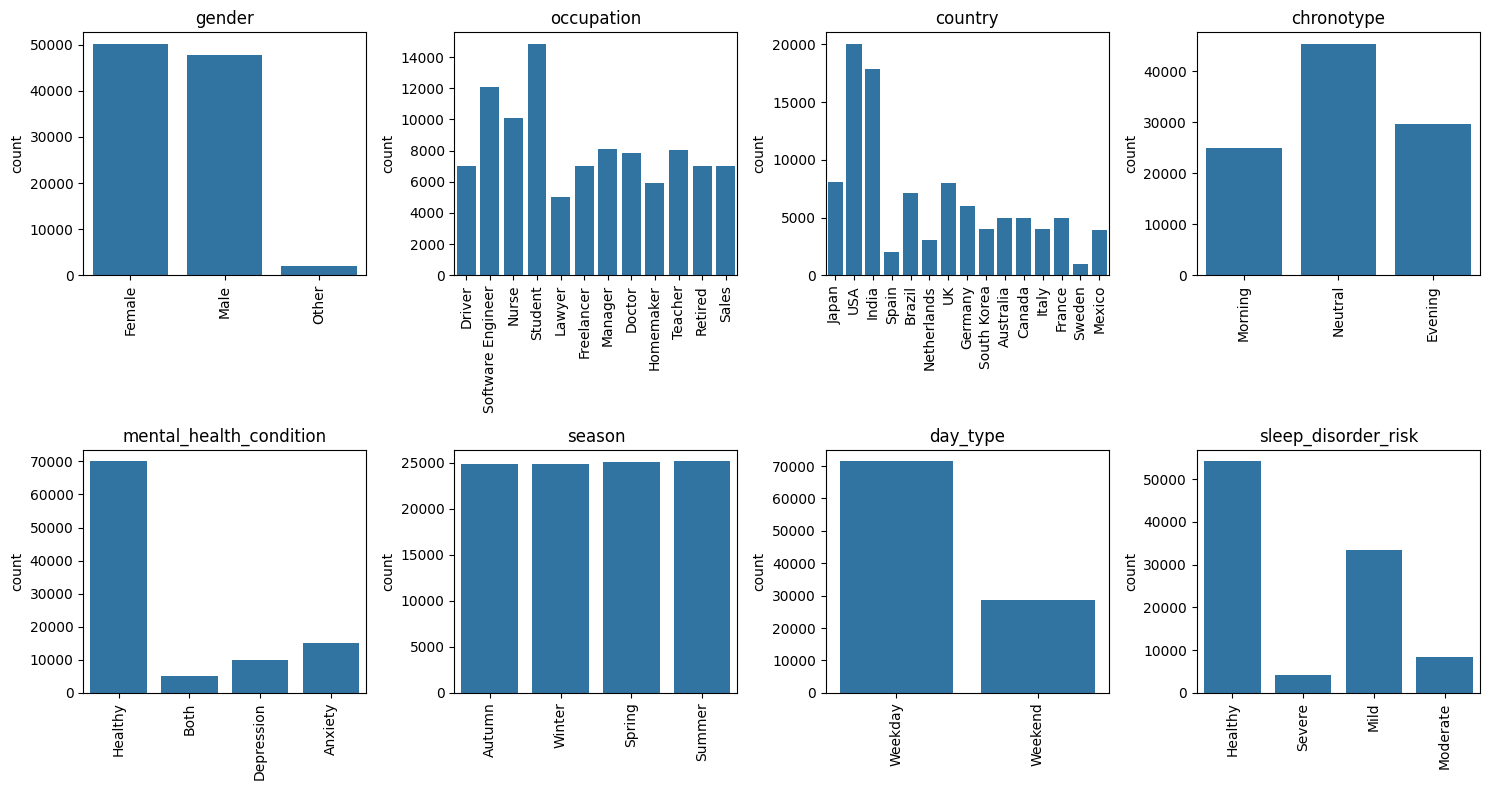

In [17]:
# Distribuciones de las columnas categoricas
categorical_cols = df.select_dtypes(include=["object"]).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 4, i + 1)
    sns.countplot(x=col, data=df)
    plt.xlabel('')
    plt.xticks(rotation=90)
    plt.title(col)

plt.tight_layout()
plt.show()

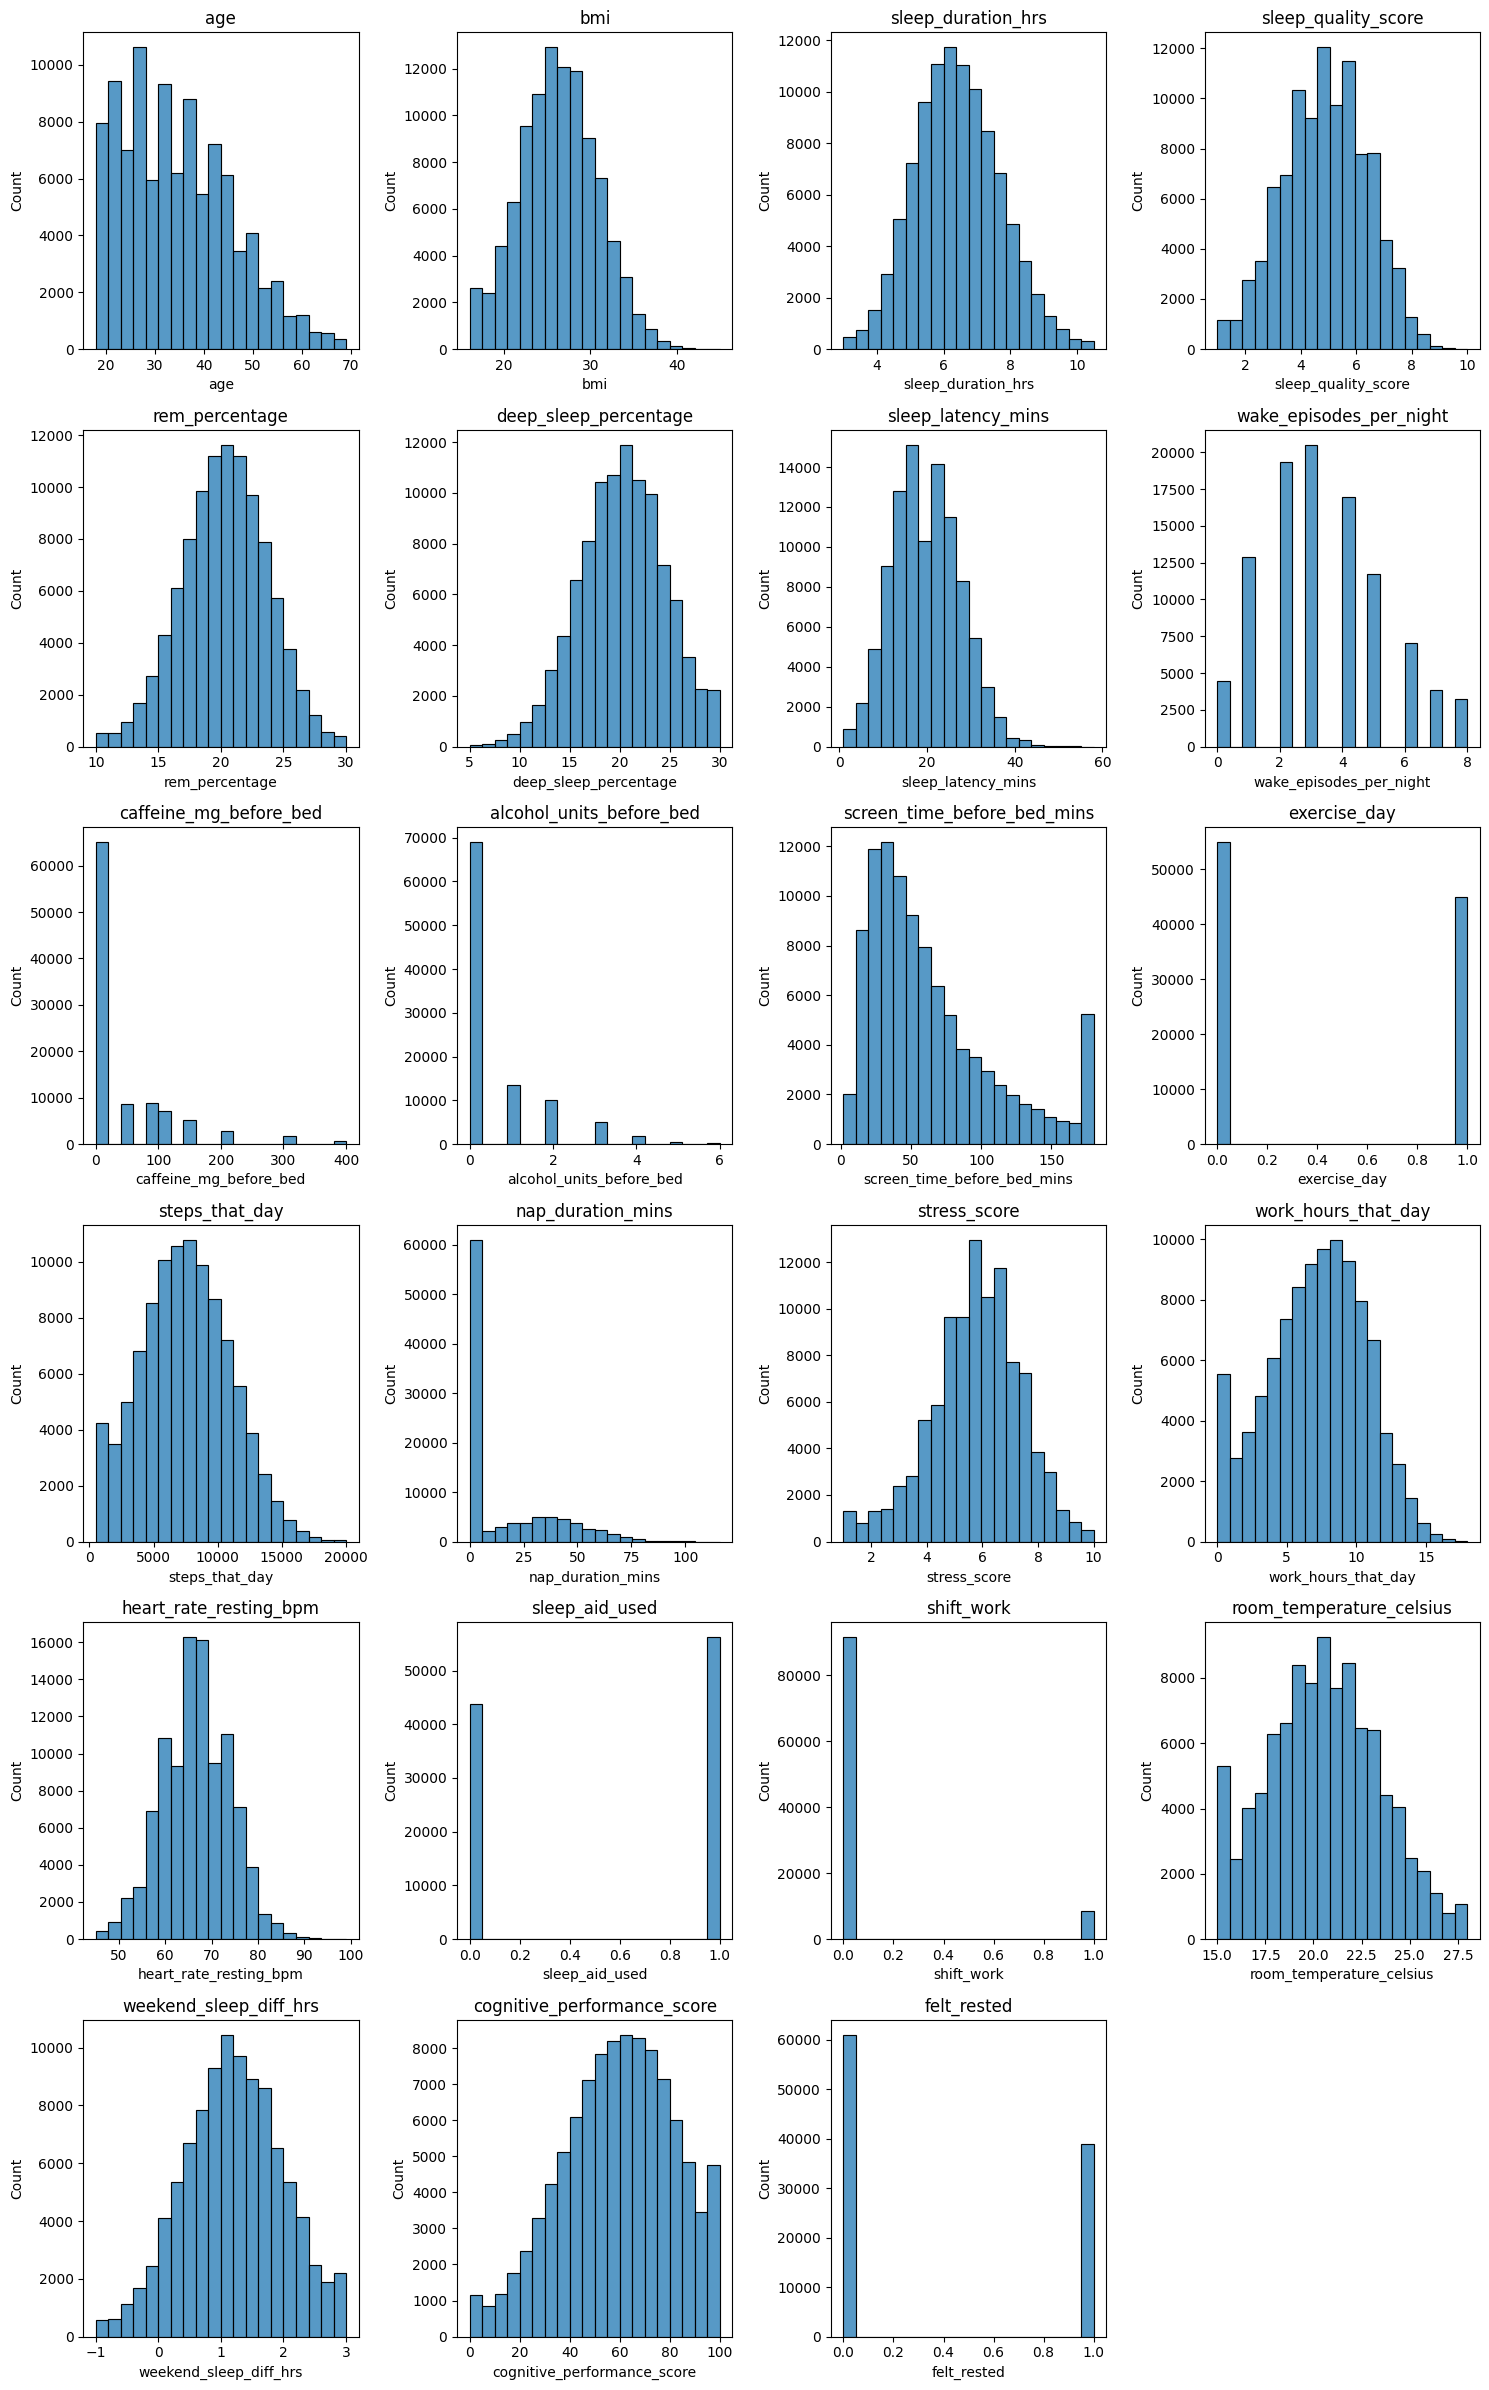

In [18]:
# Distribuciones de las columnas numéricas
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15, 24))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1)
    sns.histplot(x=col, data=df, bins=20)
    plt.xlabel(col)
    plt.title(col)

plt.tight_layout()
plt.show()

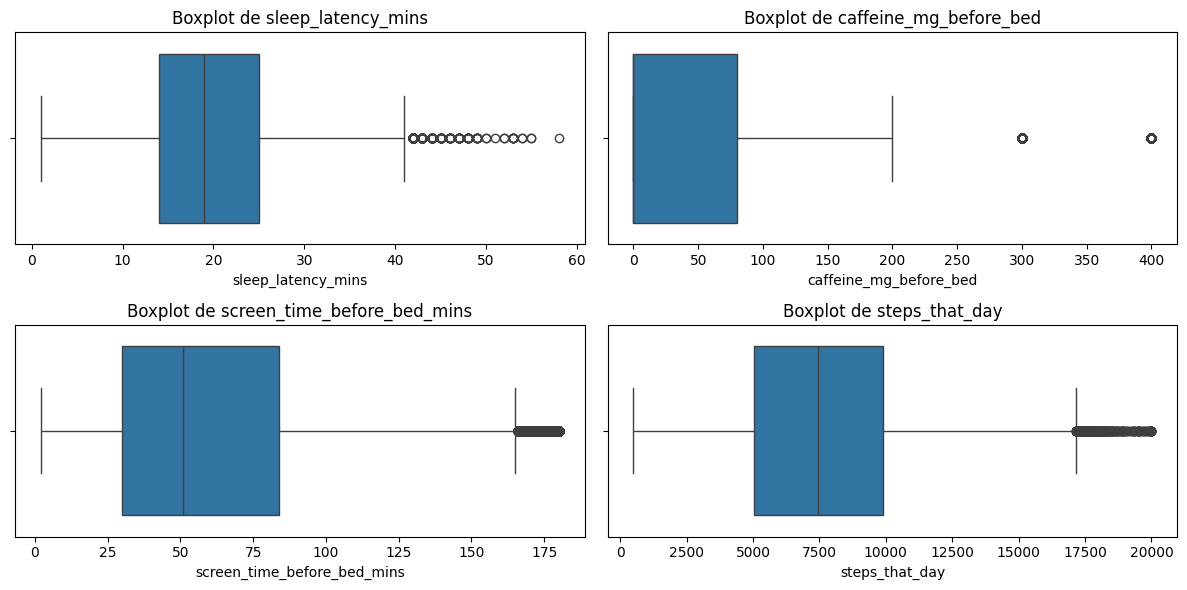

In [26]:
columnas_para_boxplots = ['sleep_latency_mins', 'caffeine_mg_before_bed', 'screen_time_before_bed_mins', 'steps_that_day']
plt.figure(figsize=(12, 6))
for i, col in enumerate(columnas_para_boxplots):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

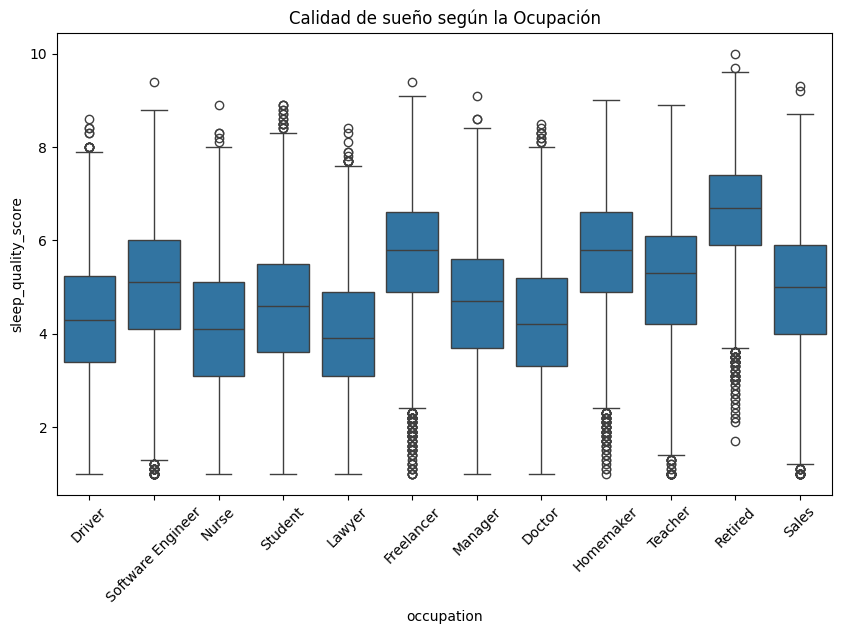

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(x='occupation', y='sleep_quality_score', data=df)
plt.xticks(rotation=45)
plt.title("Calidad de sueño según la Ocupación")
plt.show()

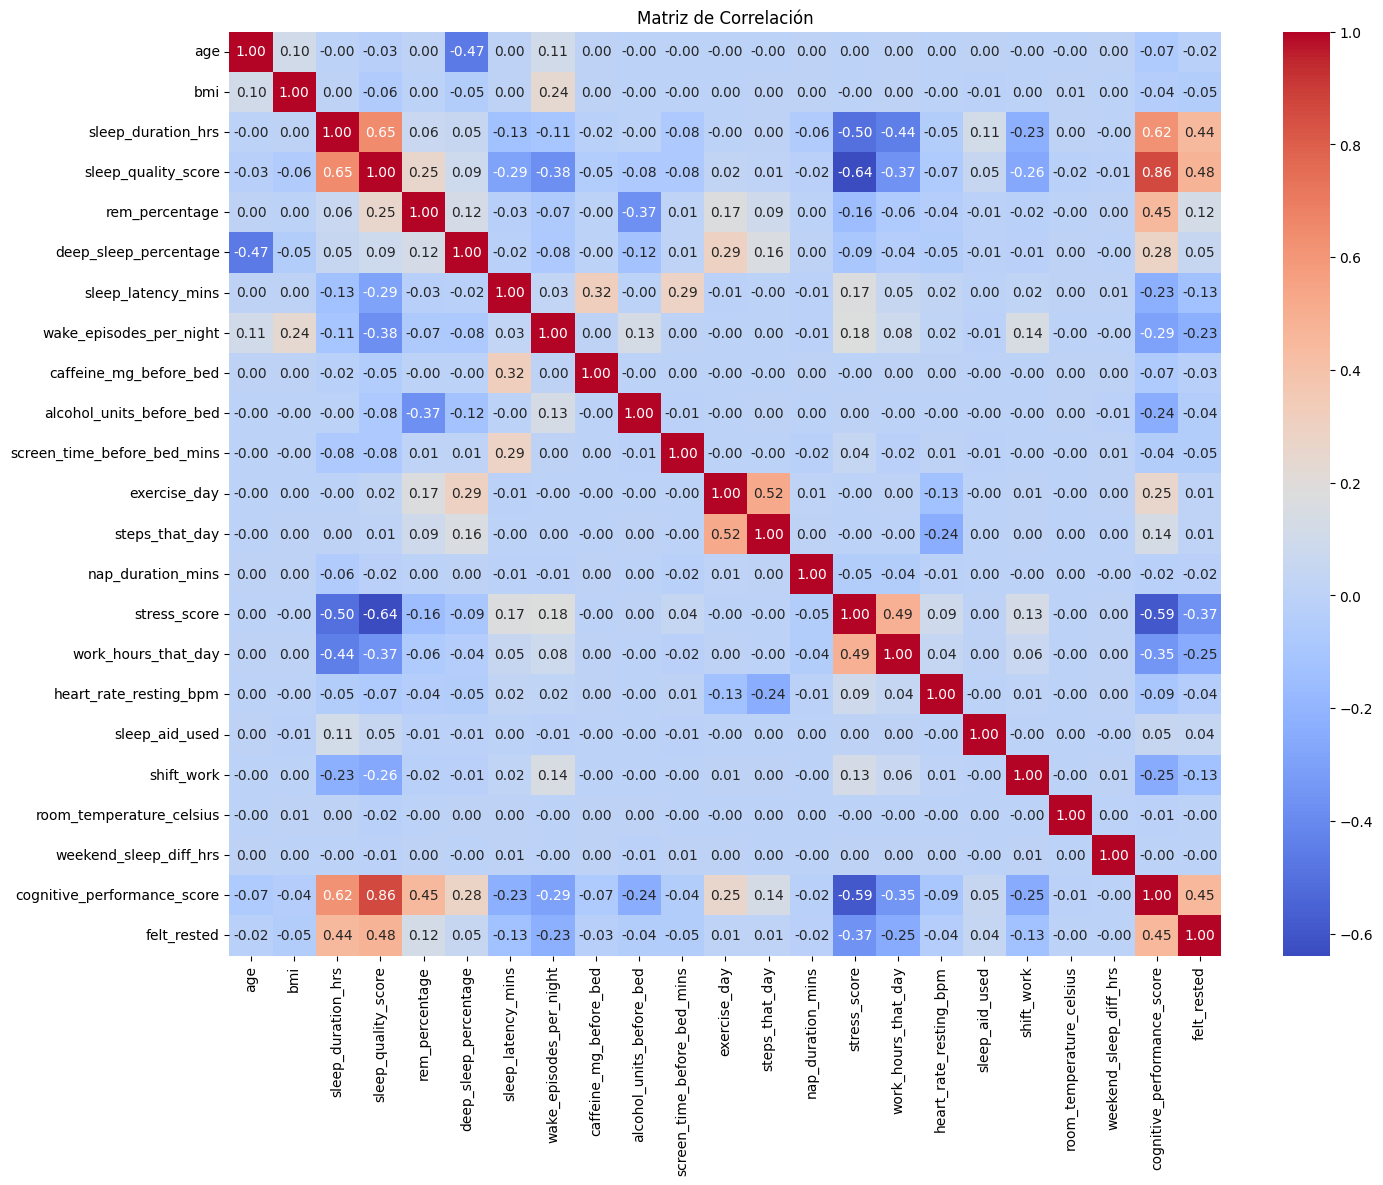

In [27]:
# Correlación entre columnas

plt.figure(figsize=(16, 12))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# Aplicación de Técnicas de Machine Learning

## Clasificación

### Selección y Justificación del Modelo:

KNN: El Árbol de Decisión funciona como un punto de partida porque traduce los datos en reglas lógicas y visuales. Esto emula directamente los árboles de diagnóstico que utilizan los profesionales de la salud.

Árbol de decisión: Random Forest, al ser un modelo de ensamble, aprovecha la cantidad masiva de datos y reduce drásticamente la varianza, garantizando que el modelo generalice de forma excelente ante nuevos pacientes.

### Entrenamiento del modelo

In [97]:
X = pd.get_dummies(df.drop(['felt_rested', 'cognitive_performance_score',
                            'sleep_disorder_risk'], axis=1), drop_first=True)
y_class = df['sleep_disorder_risk']

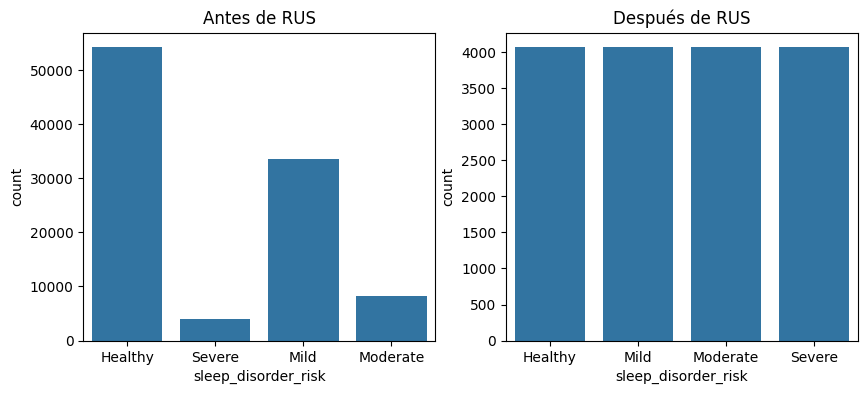

In [98]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='sleep_disorder_risk', data=df)
plt.title('Antes de RUS')

from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y_class)

plt.subplot(1, 2, 2)
sns.countplot(x='sleep_disorder_risk', data=pd.DataFrame(y_rus))
plt.title('Después de RUS')
plt.show()

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_rus, y_rus, test_size=0.2, random_state=42)

In [100]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

tree_model = DecisionTreeClassifier(max_depth=10, random_state=100)
tree_model.fit(X_train, y_train)

forest_model = RandomForestClassifier(max_depth=10, random_state=100)
forest_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

print("Árbol de decisión:")
print(classification_report(y_test, y_pred_tree))

print("\nRandom forest:")
print(classification_report(y_test, y_pred_forest))

Árbol de decisión:
              precision    recall  f1-score   support

     Healthy       0.88      0.85      0.86       801
        Mild       0.70      0.72      0.71       813
    Moderate       0.65      0.65      0.65       851
      Severe       0.78      0.79      0.78       788

    accuracy                           0.75      3253
   macro avg       0.75      0.75      0.75      3253
weighted avg       0.75      0.75      0.75      3253


Random forest:
              precision    recall  f1-score   support

     Healthy       0.90      0.91      0.91       801
        Mild       0.78      0.76      0.77       813
    Moderate       0.72      0.68      0.70       851
      Severe       0.79      0.85      0.82       788

    accuracy                           0.80      3253
   macro avg       0.80      0.80      0.80      3253
weighted avg       0.79      0.80      0.80      3253



In [88]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

forest_model = RandomForestClassifier(max_depth=10, random_state=42)
forest_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

print("Árbol de decisión:")
print(classification_report(y_test, y_pred_tree))

print("\nRandom forest:")
print(classification_report(y_test, y_pred_forest))

Árbol de decisión:
              precision    recall  f1-score   support

     Healthy       0.88      0.84      0.86       801
        Mild       0.69      0.72      0.70       813
    Moderate       0.65      0.64      0.65       851
      Severe       0.77      0.79      0.78       788

    accuracy                           0.75      3253
   macro avg       0.75      0.75      0.75      3253
weighted avg       0.75      0.75      0.75      3253


Random forest:
              precision    recall  f1-score   support

     Healthy       0.90      0.91      0.90       801
        Mild       0.77      0.76      0.76       813
    Moderate       0.71      0.67      0.69       851
      Severe       0.79      0.85      0.82       788

    accuracy                           0.79      3253
   macro avg       0.79      0.80      0.79      3253
weighted avg       0.79      0.79      0.79      3253



In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

tree_model = DecisionTreeClassifier(max_depth=10)
tree_model.fit(X_train, y_train)

forest_model = RandomForestClassifier(max_depth=10)
forest_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

print("Árbol de decisión:")
print(classification_report(y_test, y_pred_tree))

print("\nRandom forest:")
print(classification_report(y_test, y_pred_forest))

Árbol de decisión:
              precision    recall  f1-score   support

     Healthy       0.88      0.86      0.87       801
        Mild       0.70      0.71      0.71       813
    Moderate       0.65      0.66      0.65       851
      Severe       0.78      0.78      0.78       788

    accuracy                           0.75      3253
   macro avg       0.75      0.75      0.75      3253
weighted avg       0.75      0.75      0.75      3253


Random forest:
              precision    recall  f1-score   support

     Healthy       0.90      0.91      0.90       801
        Mild       0.76      0.75      0.76       813
    Moderate       0.70      0.66      0.68       851
      Severe       0.78      0.84      0.81       788

    accuracy                           0.79      3253
   macro avg       0.79      0.79      0.79      3253
weighted avg       0.78      0.79      0.78      3253



### Evaluación del Modelo

In [90]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

acc_tree = cross_val_score(tree_model, X_rus, y_rus, cv=5)
f1_tree = cross_val_score(tree_model, X_rus, y_rus, cv=5, scoring='f1_weighted')

acc_forest = cross_val_score(forest_model, X_rus, y_rus, cv=5)
f1_forest = cross_val_score(forest_model, X_rus, y_rus, cv=5, scoring='f1_weighted')

print('Árbol de decisión:')
print(f'Accuracy promedio: {acc_tree.mean():.2f} con desviacion de: {acc_tree.std():.2f}')
print(f'F1 promedio: {f1_tree.mean():.2f} con desviacion de: {f1_tree.std():.2f}')
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))

print('\nRandom forest:')
print(f'Accuracy promedio: {acc_forest.mean():.2f} con desviacion de: {acc_forest.std():.2f}')
print(f'F1 promedio: {f1_forest.mean():.2f} con desviacion de: {f1_forest.std():.2f}')
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_forest))

Árbol de decisión:
Accuracy promedio: 0.75 con desviacion de: 0.00
F1 promedio: 0.75 con desviacion de: 0.00
Matriz de confusión:
[[686 114   1   0]
 [ 91 580 137   5]
 [  2 121 558 170]
 [  0   8 165 615]]

Random forest:
Accuracy promedio: 0.80 con desviacion de: 0.01
F1 promedio: 0.80 con desviacion de: 0.00
Matriz de confusión:
[[727  74   0   0]
 [ 79 609 121   4]
 [  0 109 560 182]
 [  0   6 121 661]]


### Comparación de Resultados

In [91]:
class_metrics = {
    'Arbol de decision': [acc_tree.mean(), acc_tree.std(), f1_tree.mean(), f1_tree.std()],
    'Random forest': [acc_forest.mean(), acc_forest.std(), f1_forest.mean(), f1_forest.std()]
}

comparativa_class = pd.DataFrame(class_metrics, index=['Accuracy promedio', 'Accuracy desviacion', 'F1 promedio', 'F1 desviacion'])

comparativa_class

,Arbol de decision,Random forest
Accuracy promedio,0.747356,0.801156
Accuracy desviacion,0.003372,0.006401
F1 promedio,0.746223,0.800524
F1 desviacion,0.002151,0.003494


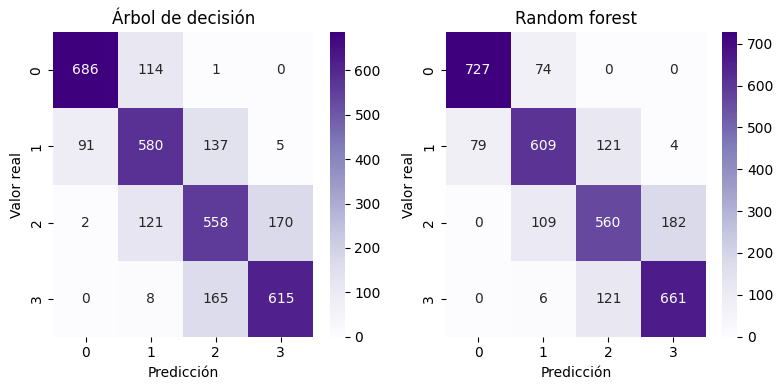

In [92]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='.0f', cmap='Purples')
plt.title('Árbol de decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='.0f', cmap='Purples')
plt.title('Random forest')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.show()

Por su propia naturaleza de ensamble, el modelo Random Forest presenta una ligera mejora respecto al árbol de decisión individual, ya que combina múltiples árboles para reducir la varianza y el sobreajuste. Aunque la diferencia en las métricas no es drástica, aporta una mayor estabilidad y robustez a las predicciones.


### Conclusiones Técnicas

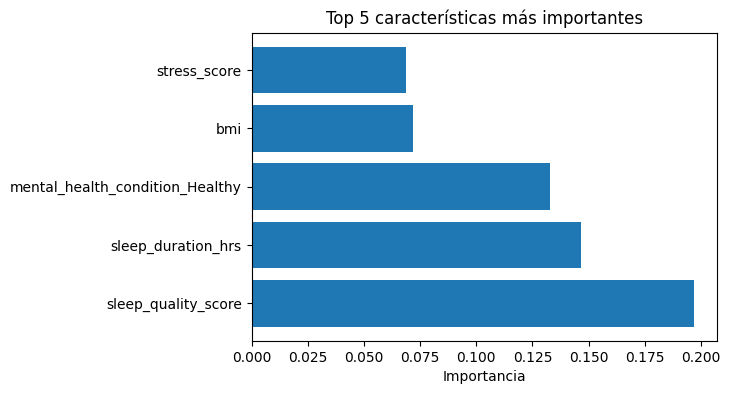

In [106]:
importances = forest_model.feature_importances_
feature_names = X_rus.columns

top_5_indices = importances.argsort()[-5:][::-1]
top_5_features = feature_names[top_5_indices]
top_5_importances = importances[top_5_indices]

plt.figure(figsize=(6, 4))
plt.barh(top_5_features, top_5_importances)
plt.xlabel('Importancia')
plt.title('Top 5 características más importantes')
plt.show()

Se determina que el riesgo de trastornos no está condicionado por una sola variable aislada. Al utilizar modelos basados en árboles, el análisis logra asimilar de manera eficiente variables categóricas, capturando divisiones lógicas intuitivas en la población que se asemejan a los criterios de diagnóstico clínico.

Para el siguiente análisis se desea estudiar formalmente la importancia de características para identificar y retener únicamente aquellas variables que aporten un peso estadístico real al modelo, descartando columnas redundantes o irrelevantes.

## Regresión

* Selección y Justificación del Modelo:

Elegir al menos dos algoritmos distintos (por ejemplo: SVM, redes neuronales, nose q mas pueda ir en regresion, etc.) y justificar su elección con base en el tipo de datos y la tarea a resolver.

* Entrenamiento del Modelo:

Realizar el proceso completo de entrenamiento con los datos preparados. Al menos tres ejecuciones del modelo con diferentes particiones o semillas aleatorias para validar la estabilidad de los resultados.

* Evaluación del Modelo:

Para regresión: MAE, RMSE, R².

* Comparación de Resultados:

**Tabla comparativa** de los modelos utilizados y sus respectivas métricas.
Justificar cuál modelo es más adecuado para el problema abordado, con base en los resultados obtenidos y su coherencia con el contexto del conjunto de datos.

* Conclusiones Técnicas:

**Redactar** un apartado donde se analicen los hallazgos obtenidos a partir del modelo (o modelos) seleccionados, incluyendo limitaciones, posibles mejoras y recomendaciones para futuras versiones del análisis.

In [ ]:
y_reg = df['cognitive_performance_score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

MSE: 49.51624612300319
R2: 0.8992385078929722
MAE: 5.529094293415574


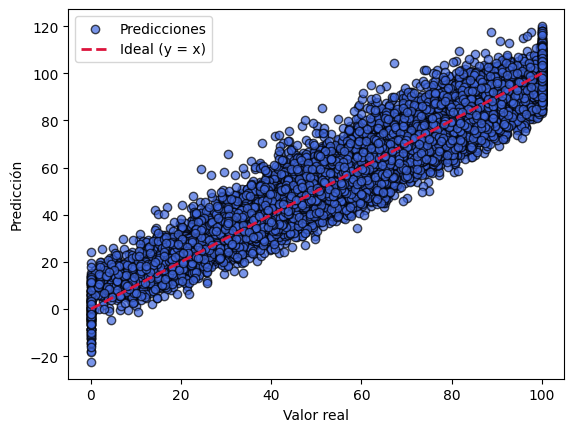

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

plt.scatter(y_test, y_pred, color="royalblue", alpha=0.7, edgecolor="k", label="Predicciones")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="crimson", lw=2, linestyle="--", label="Ideal (y = x)")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.legend()
plt.show()

## Clustering

Selección y Justificación del Modelo:

Elegir al menos dos algoritmos distintos (por ejemplo: redes neuronales, clustering k-means, idk q mas vaya con clustering, etc.) y justificar su elección con base en el tipo de datos y la tarea a resolver.

* Entrenamiento del Modelo:

Realizar el proceso completo de entrenamiento con los datos preparados. Al menos tres ejecuciones del modelo con diferentes particiones o semillas aleatorias para validar la estabilidad de los resultados.

* Evaluación del Modelo:

Para clustering: silueta, inercia, etc.

* Comparación de Resultados:

**Tabla comparativa** de los modelos utilizados y sus respectivas métricas.
Justificar cuál modelo es más adecuado para el problema abordado, con base en los resultados obtenidos y su coherencia con el contexto del conjunto de datos.

* Conclusiones Técnicas:

**Redactar** un apartado donde se analicen los hallazgos obtenidos a partir del modelo (o modelos) seleccionados, incluyendo limitaciones, posibles mejoras y recomendaciones para futuras versiones del análisis.

#Eleccion de los modelos de Clustering

**K-Means**: Es un modelo de clustering bastante comun y robusto, el cual nos ayuda a generar grupos por la distancia entre cada punto, generando clusters donde haya una mayor concentración de datos. Fue elegido para este dataset debido a su practicidad y bastante util como punto de partida para esta seccion

**Gaussian Mixture Model**: Es un modelo de clustering bastante flexible y rápido. Calcula la probabilidad de que cada dato aparezca en un grupo, generando así los clusters. Fue elegido para este dataset por su flexibilidad ante datos atípicos

In [ ]:
#Obtenemos de nuevo el dataframe
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df_kms = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')

#Ahora, escalamos el dataset y seleccionamos las columnas objetivo

columnas_deseadas = [
    "age",
    "bmi",
    "sleep_duration_hrs",
    "rem_percentage",
    "screen_time_before_bed_mins",
    "stress_score",
    'sleep_latency_mins',
    "room_temperature_celsius",
    "work_hours_that_day",
    "sleep_quality_score",
    "wake_episodes_per_night",
    'heart_rate_resting_bpm',
    'cognitive_performance_score'
]
X = df_kms[columnas_deseadas].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Fijamos a 3 clusters debido a los resultados obtenidos en el Silhouette Score del siguiente bloque
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

df_kms["cluster"] = kmeans.labels_

#Reducimos a 2 dimensiones para poder englobar todas nuestras variables en la tabla (y no tener que hacer un grafico
# de multiples dimensiones)
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_kms["PCA1"] = componentes[:, 0]
df_kms["PCA2"] = componentes[:, 1]

centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_kms, x="PCA1", y="PCA2", hue="cluster", palette="viridis", alpha=0.7
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroides",
)

# Detalles estéticos
plt.title(
    "Visualización de Clusters de Sueño (PCA 2D)", fontsize=14, fontweight="bold"
)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.legend(loc="upper right", title="Clusters")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [ ]:
#Verificamos que el kmeans sea correcto con Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

# Rango de valores de K a probar
range_n_clusters = range(2, 10)

silhouette_scores = []

for k in range_n_clusters:
    # Entrenar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Calcular silhouette score
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

# Graficar resultados
plt.figure(figsize=(8,5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Score para diferentes valores de K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [ ]:
#Seguna ejecucion de K-Means
#Obtenemos de nuevo el dataframe

#Fijamos a 3 clusters debido a los resultados obtenidos en el Silhouette Score del siguiente bloque
kmeans = KMeans(n_clusters=3, random_state=12)
kmeans.fit(X_scaled)

df_kms["cluster"] = kmeans.labels_

#Reducimos a 2 dimensiones para poder englobar todas nuestras variables en la tabla (y no tener que hacer un grafico
# de multiples dimensiones)
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_kms["PCA1"] = componentes[:, 0]
df_kms["PCA2"] = componentes[:, 1]

centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_kms, x="PCA1", y="PCA2", hue="cluster", palette="viridis", alpha=0.7
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroides",
)

# Detalles estéticos
plt.title(
    "Visualización de Clusters de Sueño (PCA 2D)", fontsize=14, fontweight="bold"
)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.legend(loc="upper right", title="Clusters")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

#Fijamos a 3 clusters debido a los resultados obtenidos en el Silhouette Score del siguiente bloque
kmeans = KMeans(n_clusters=3, random_state=5)
kmeans.fit(X_scaled)

df_kms["cluster"] = kmeans.labels_

#Reducimos a 2 dimensiones para poder englobar todas nuestras variables en la tabla (y no tener que hacer un grafico
# de multiples dimensiones)
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_kms["PCA1"] = componentes[:, 0]
df_kms["PCA2"] = componentes[:, 1]

centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_kms, x="PCA1", y="PCA2", hue="cluster", palette="viridis", alpha=0.7
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroides",
)

# Detalles estéticos
plt.title(
    "Visualización de Clusters de Sueño (PCA 2D)", fontsize=14, fontweight="bold"
)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.legend(loc="upper right", title="Clusters")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [ ]:
#Ahora hacemos clustering con Gaussian Mixture Model
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df_gmm = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')

columnas_deseadas = [
    "age",
    "bmi",
    "sleep_duration_hrs",
    "rem_percentage",
    "screen_time_before_bed_mins",
    "stress_score",
    'sleep_latency_mins',
    "room_temperature_celsius",
    "work_hours_that_day",
    "sleep_quality_score",
    "wake_episodes_per_night",
    'heart_rate_resting_bpm',
    'cognitive_performance_score'
]
X = df_gmm[columnas_deseadas].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 3 #Fijamos a 3 por el resultado obtenido en la tabla de resultados de abajo
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_scaled)

X["cluster"]      = gmm.predict(X_scaled)          # cluster asignado (0, 1, 2...)
X["prob_max"]     = gmm.predict_proba(X_scaled).max(axis=1)  # confianza de asignación
X["log_score"]    = gmm.score_samples(X_scaled)    # log-verosimilitud (outlier detection)

df_gmm1 = df_gmm.join(X[["cluster", "prob_max", "log_score"]], how="left")

#Ahora Comparamos los resultados desde k=2 hasta k=9 de la metrica bic (Bayesian Information Criterion)
# y aic (Akaike Information Criterion)
from sklearn.mixture import GaussianMixture
import numpy as np

resultados = []

for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    resultados.append({
        "k":   k,
        "bic": gmm.bic(X_scaled),   # menor = mejor
        "aic": gmm.aic(X_scaled),   # menor = mejor
        "log_likelihood": gmm.score(X_scaled)  # mayor = mejor, pero siempre sube
    })

df_res = pd.DataFrame(resultados)
print(tabulate(df_res, headers='keys', tablefmt="pretty"))

In [ ]:
#Ahora realizamos las siguientes 2 ejecuciones de GMM

n_clusters = 3 #Fijamos a 3 por el resultado obtenido en la tabla de resultados de abajo
gmm = GaussianMixture(n_components=n_clusters, random_state=56)
gmm.fit(X_scaled)

X["cluster"]      = gmm.predict(X_scaled)          # cluster asignado (0, 1, 2...)
X["prob_max"]     = gmm.predict_proba(X_scaled).max(axis=1)  # confianza de asignación
X["log_score"]    = gmm.score_samples(X_scaled)    # log-verosimilitud (outlier detection)

df_gmm2 = df_gmm.join(X[["cluster", "prob_max", "log_score"]], how="left")

n_clusters = 3 #Fijamos a 3 por el resultado obtenido en la tabla de resultados de abajo
gmm = GaussianMixture(n_components=n_clusters, random_state=6)
gmm.fit(X_scaled)

X["cluster"]      = gmm.predict(X_scaled)          # cluster asignado (0, 1, 2...)
X["prob_max"]     = gmm.predict_proba(X_scaled).max(axis=1)  # confianza de asignación
X["log_score"]    = gmm.score_samples(X_scaled)    # log-verosimilitud (outlier detection)

df_gmm3 = df_gmm.join(X[["cluster", "prob_max", "log_score"]], how="left")

#Comparamos con gmm1, gmm2 y gmm3
columnas_analisis = columnas_deseadas + ['cluster']
gmm1 = df_gmm1[columnas_analisis].groupby('cluster').mean()
gmm2 = df_gmm2[columnas_analisis].groupby('cluster').mean()
gmm3 = df_gmm3[columnas_analisis].groupby('cluster').mean()
print(tabulate(gmm1, headers='keys', tablefmt="pretty"))
print(tabulate(gmm2, headers='keys', tablefmt="pretty"))
print(tabulate(gmm3, headers='keys', tablefmt="pretty"))

Podemos observar que los resultados se mantienen entre cada ejecucion distinta de GMM, el unico cambio es en el orden de los datos

In [ ]:
#Mostramos una tabla por mada modelo utilizado
from tabulate import tabulate
columnas_analisis = columnas_deseadas + ['cluster']

tabla_promedios_gmm = df_gmm1[columnas_analisis].groupby('cluster').mean()
tabla_promedios_kms = df_kms[columnas_analisis].groupby('cluster').mean()

print(tabulate(tabla_promedios_gmm, headers='keys', tablefmt="pretty"))
print(tabulate(tabla_promedios_kms, headers='keys', tablefmt="pretty"))

Con las tablas anteriores, podemos observar que, aunque los clusteres comparten edad, imc, porcentaje rem, temperatura promedio y latidos por minuto promedio similares, notamos que el primer grupo suele tener un horario de sueño estandar para un adulto, con un nivel de estres medio y y una calidad de sueño descente, mientras que el segundo grupo que duerme mas horas, suele tener una mejor calidad de sueño y suele tener una menor cantidad de estres. Por ultimo, el tercer grupo que duerme menos horas y trabaja mas horas, suele tener una mayor cantidad de estrés

# dianamamada

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [ ]:
#instancia de label encoder para convertir las variables categoricas a numericas
label_encoder = preprocessing.LabelEncoder()
dataD= df.copy().drop(['felt_rested', 'cognitive_performance_score','sleep_disorder_risk'], axis=1)
for columna in dataD.select_dtypes(include=["object"]).columns:
    dataD[columna] = label_encoder.fit_transform(dataD[columna])

y_d= df['sleep_disorder_risk']

In [ ]:
dataD.head()

In [ ]:
X_trainD, X_testD, y_trainD, y_testD = train_test_split(dataD, y_d, test_size=0.2, random_state=42)

pipeline=Pipeline([('escalar', StandardScaler()),('lr',LogisticRegression())])

# hiperparametros del pipeline y ajustar GridSearchCV
hiperparametros= [
    {'lr': [RandomForestClassifier()],
     'lr__n_estimators': [100, 200, 300],
     'lr__max_depth': [5, 10, 15, 30]},
    {'lr': [SVC()],
     'lr__kernel': ['sigmoid', 'rbf'],
     'lr__C': [0.01, 0.1, 1, 10]},
    {'lr': [LogisticRegression(max_iter=1000)],
     'lr__solver': ['liblinear', 'lbfgs'],
     'lr__C': [0.01, 0.1, 1, 10]},
    {'lr': [KNeighborsClassifier()],
     'lr__n_neighbors': [3, 5, 7, 9]},
    {'lr': [GradientBoostingClassifier()],
     'lr__n_estimators': [100, 200, 300, 400],
     'lr__learning_rate': [0.01, 0.1, 1]}
]

gs = GridSearchCV(pipeline,hiperparametros, cv=7)
gs.fit(X_trainD, y_trainD)

mejorModelo= gs.best_estimator_

modelos = [
    ('Random Forest', RandomForestClassifier()),
    ('SVM', SVC()),
    ('Logistic Regression', LogisticRegression()),
    ('KNN', KNeighborsClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier())
]

accuracy_scores = []
for n,m in modelos:
    pipeline = Pipeline([('escalar', StandardScaler()),('lr',m)])

    
    pipeline.fit(X_trainD, y_trainD)
    y_pred = pipeline.predict(X_test)
    precision = accuracy_score(y_test, y_pred)
    accuracy_scores.append(precision)